In [57]:

import gfapy
import networkx as nx
import numpy as np
from itertools import product, combinations
from dimod import BQM
from dwave.system import LeapHybridSampler
from math import floor
import re
import matplotlib.pyplot as plt


In [58]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into an oriented graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for segment_line in gfa.segments:
        graph.add_node(f'{segment_line.name}_+', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
        graph.add_node(f'{segment_line.name}_-', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        graph.add_edges_from([
            (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
        ])
        v1.invert()
        v2.invert()
        graph.add_edges_from([
            (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
        ])
    return graph

In [59]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [60]:
# g = oriented_graph_from_file('../../data/test.gfa')
g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k201.utg.final.gfa')
g = normalise_node_weights(g, 100)

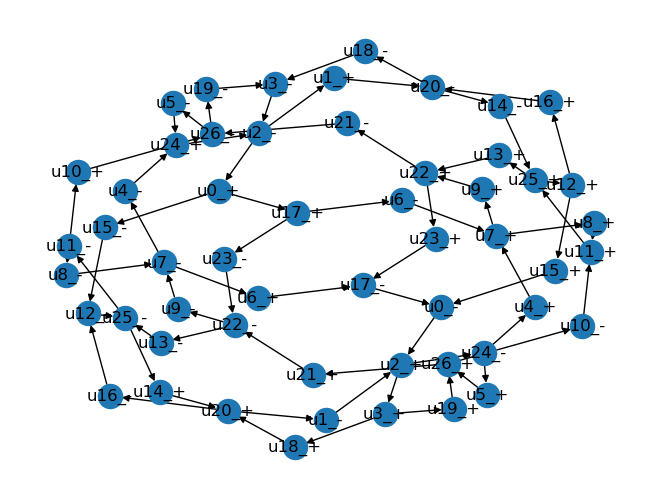

In [61]:
nx.draw_kamada_kawai(g, with_labels=True)

In [62]:
nodes = list(g.nodes)
V = int(len(nodes) / 2)
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)

lambda_t = 4
lambda_g = 2
lambda_w = 1 

In [63]:
qubo_matrix = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))

# Path constraint
for t in range(T_max):
    for i in range(V):
        for b in range(2):
            qubo_matrix[t, i, b, t, i, b] -= lambda_t
            qubo_matrix[t, V, 0, t, i, b] += 2 * lambda_t
    qubo_matrix[t, V, 0, t, V, 0] -= lambda_t
    
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (i == j and bi == bj):
            qubo_matrix[t, i, bi, t, j, bj] += lambda_t

# Graph step constraints
for t in range(T_max - 1):
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (nodes[2 * i + bi], nodes[2 * j + bj]) in g.edges:
            qubo_matrix[t, i, bi, t+1, j, bj] += lambda_g
    for i, bi in product(range(V), range(2)):
        qubo_matrix[t, V, 0, t+1, i, bi] += lambda_g
            
# Weights constraints
for i in range(V):
    for t in range(T_max):
        for b in range(2):
            qubo_matrix[t, i, b, t, i, b] -= (2 * g.nodes[nodes[2 * i]]["weight"] - 1) * lambda_w
    
    for t1, t2 in product(range(T_max), range(T_max)):
        for b1, b2 in product(range(2), range(2)):
            if not (t1 == t2 and b1 == b2):
                qubo_matrix[t1, i, b1, t2, i, b2] += lambda_w


In [64]:

qubo_matrix = qubo_matrix.reshape((T_max * (V+1) * 2), (T_max * (V+1) * 2))
qubo_matrix = 0.5 * (qubo_matrix + qubo_matrix.T)

# Delete excess rows and columns
qubo_matrix = np.delete(qubo_matrix, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)
qubo_matrix = np.delete(qubo_matrix, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 1)

In [65]:
offset = lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))
bqm = BQM(qubo_matrix, 'BINARY')
bqm.offset = offset
bqm.offset


289.0

In [66]:
print(bqm.num_variables)
print(bqm.num_interactions)
print(max(bqm.degrees().values()))
print(np.max(qubo_matrix))
print(np.min(qubo_matrix))

2805
352935
257
5.0
-11.0


In [67]:
hybrid_sampler = LeapHybridSampler()
hybrid_sampleset = hybrid_sampler.sample(bqm, label="Oriented Tangle Testing", time_limit=60)

In [68]:
hybrid_sample = hybrid_sampleset.first.sample
hybrid_energy = hybrid_sampleset.first.energy
hybrid_sample_list = np.array(list(hybrid_sample.values()))
hybrid_sample_list_copy = np.copy(hybrid_sample_list)
for idx in [t * (V+1) *2 + V * 2 + 1 for t in range(T_max)]:
    hybrid_sample_list_copy = np.insert(hybrid_sample_list_copy, idx, 0)
hybrid_sample_array = hybrid_sample_list_copy.reshape((T_max, V + 1, 2))

In [69]:
print(hybrid_energy)

4.0


In [55]:
def array_to_path(arr):
    nz = np.nonzero(arr == 1)
    return [(nz[0][i], nz[1][i], nz[2][i]) for i in range(nz[0].shape[0])]
        

In [56]:
print(array_to_path(hybrid_sample_array))

[(0, 15, 0), (1, 0, 1), (2, 2, 0), (3, 3, 0), (4, 19, 0), (5, 26, 0), (6, 10, 1), (7, 11, 0), (8, 25, 0), (9, 12, 0), (10, 16, 0), (11, 12, 1), (12, 25, 1), (13, 11, 1), (14, 8, 1), (15, 7, 1), (16, 6, 0), (17, 17, 1), (18, 0, 1), (19, 2, 0), (20, 24, 1), (21, 5, 0), (22, 26, 0), (23, 21, 0), (24, 22, 1), (25, 13, 1), (26, 25, 1), (27, 14, 0), (28, 20, 0), (29, 1, 1), (30, 2, 0), (31, 3, 0), (32, 18, 0), (33, 20, 0), (34, 1, 1), (35, 2, 0), (36, 24, 1), (37, 4, 0), (38, 7, 0), (39, 9, 0), (40, 22, 0), (41, 23, 0), (42, 17, 1), (43, 0, 1), (44, 27, 0), (45, 27, 0), (46, 27, 0), (47, 27, 0), (48, 27, 0), (49, 27, 0), (50, 27, 0)]


In [21]:
Q1 = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))

# Path constraint
for t in range(T_max):
    for i in range(V):
        for b in range(2):
            Q1[t, i, b, t, i, b] -= lambda_t
            Q1[t, V, 0, t, i, b] += 2 * lambda_t
    Q1[t, V, 0, t, V, 0] -= lambda_t
    
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (i == j and bi == bj):
            Q1[t, i, bi, t, j, bj] += lambda_t
            
    
Q1 = Q1.reshape((T_max * (V+1) * 2), (T_max * (V+1) * 2))
Q1 = 0.5 * (Q1 + Q1.T)

# Delete excess rows and columns
Q1 = np.delete(Q1, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)
Q1 = np.delete(Q1, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 1)

In [22]:
Q2 = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))

# Graph step constraints
for t in range(T_max - 1):
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (nodes[2 * i + bi], nodes[2 * j + bj]) in g.edges:
            Q2[t, i, bi, t+1, j, bj] += lambda_g
    for i, bi in product(range(V), range(2)):
        Q2[t, V, 0, t+1, i, bi] += lambda_g


Q2 = Q2.reshape((T_max * (V+1) * 2), (T_max * (V+1) * 2))
Q2 = 0.5 * (Q2 + Q2.T)

# Delete excess rows and columns
Q2 = np.delete(Q2, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)
Q2 = np.delete(Q2, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 1)

In [23]:
Q3 = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))
            
# Weights constraints
for i in range(V):
    for t in range(T_max):
        for b in range(2):
            Q3[t, i, b, t, i, b] -= (2 * g.nodes[nodes[2 * i]]["weight"] - 1) * lambda_w
    
    for t1, t2 in product(range(T_max), range(T_max)):
        for b1, b2 in product(range(2), range(2)):
            if not (t1 == t2 and b1 == b2):
                Q3[t1, i, b1, t2, i, b2] += lambda_w
                

Q3 = Q3.reshape((T_max * (V+1) * 2), (T_max * (V+1) * 2))
Q3 = 0.5 * (Q3 + Q3.T)

# Delete excess rows and columns
Q3 = np.delete(Q3, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)
Q3 = np.delete(Q3, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 1)


In [ ]:
# k501 path
# best_path_nodes = ['u5-','u3-','u0-','u2+','u9+','u6-','u5+','u4-','u0-','u2+','u9+','u11+','u15+','u16+','u14-','u13-','u12+','u11-','u9-','u2-','u1+','u13-','u10-','u9-','u8+','u16-','u7-', 'u5-']

# k101 path
best_path_nodes = ["u21+","u23+","u25+","u27+","u39-","u30-","u29-","u24-","u23+","u25+","u0-","u2+","u3+","u6+","u10-","u37+","u5-","u3-","u2-","u1+","u11-","u12+","u14+","u38-","u16+","u35+","u32-","u33+","u34+","u40-","u7-","u3-","u2-","u1+","u36-","u35-","u20-","u18-","u17+","u39+","u26-","u23-","u21-","u19-","u18-","u15-","u38+","u13-","u12-","u9-","u37+","u8+","u29+","u31+","u40-","u4-","u3+","u6+","u28+","u33-","u22-"]


best_path_sample = np.zeros((T_max, V+1, 2))
for i in range(len(best_path_nodes)):
    node_matches = re.search(
        r'(.+)([\+\-])',
        best_path_nodes[i]
    )
    node_name = f"{node_matches[1]}_{node_matches[2]}"
    best_path_sample[i, floor(nodes.index(node_name) /2), nodes.index(node_name) % 2] = 1
best_path_sample[i+1:, -1, 0] = 1
print(array_to_path(best_path_sample))

In [30]:
best_sample = best_path_sample.reshape((T_max * (V+1) * 2),)
best_sample = np.delete(best_sample, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)


In [ ]:
best_sample @ qubo_matrix @ best_sample

In [27]:
offset = lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))
offset

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spy(qubo_matrix)
plt.show()


In [ ]:
nz =np.nonzero(qubo_matrix)
len(nz[0])

In [ ]:
qubo_matrix.size

In [ ]:
2 ** qubo_matrix.shape[0]

In [ ]:
d = 5
samples = np.zeros((2 ** d, qubo_matrix.shape[0]))
for vars in product([0, 1], repeat=d):
    samples[0:d]

In [11]:
def binary_vectors_with_k_ones(m, k):
    # Create a list to store the valid binary vectors
    result = []
    
    # Loop over the possible number of 1's from 0 to k
    for num_ones in range(k + 1):
        # Get all combinations of positions for the 1's
        for ones_positions in combinations(range(m), num_ones):
            # Create a binary vector of length m with 0's
            vector = np.zeros(m, dtype=int)
            # Set the positions of the vector to 1 where the combination indicates
            vector[list(ones_positions)] = 1
            result.append(vector)
    
    # Convert the list of vectors into a NumPy array
    return np.array(result)

In [14]:
def binary_vectors_with_k_ones_batch(m, k, batch_size):
    batch = []
    for num_ones in range(k + 1):
        for ones_positions in combinations(range(m), num_ones):
            vector = np.zeros(m, dtype=int)
            vector[list(ones_positions)] = 1
            batch.append(vector)
            if len(batch) >= batch_size:
                yield np.array(batch)
                batch = []
    if batch:  # Yield the remaining vectors in the final batch
        yield np.array(batch)

In [ ]:
all_energies = np.array([])
for bins in binary_vectors_with_k_ones_batch(qubo_matrix.shape[0], 5, 100):
    energies = np.einsum("ij,ji->i", (bins @ qubo_matrix), bins.T) + offset
    all_energies = np.hstack((all_energies, energies))
    
plt.hist(all_energies)
plt.show()

In [ ]:
bins = binary_vectors_with_k_ones(qubo_matrix.shape[0], 4)

energies = np.einsum("ij,ji->i", (bins @ qubo_matrix), bins.T) + offset
plt.hist(energies)
plt.show()

In [ ]:
all_energies[0]

In [ ]:
import dwave.inspector
from dwave.system import DWaveSampler, EmbeddingComposite, FixedEmbeddingComposite
sampler = EmbeddingComposite(DWaveSampler())
num_reads = 1000
sampleset = sampler.sample_qubo(qubo_matrix, num_reads=num_reads, label='SDK Examples - Inspector')
print(f'Energy: {sampleset.first.energy}')
print("Percentage of samples with high rates of breaks is {}.".format(
       np.count_nonzero(sampleset.record.chain_break_fraction > 0.05)/num_reads*100))
dwave.inspector.show(sampleset)      

In [52]:
from dimod import to_networkx_graph

from dwave_networkx import chimera_graph, pegasus_graph
from minorminer import find_embedding



In [54]:
bqm_graph = to_networkx_graph(bqm)
pegasus = pegasus_graph(7)
embedding = find_embedding(bqm_graph, pegasus, random_seed=10)
print(embedding)

KeyboardInterrupt: embedding cancelled by keyboard interrupt

In [ ]:
sampler.properties